# Fastest Lap Analysis

Analyses the historical distribution of fastest lap by grid and finish position to inform the probability function used in .

Currently stubbed as a flat 5% for all drivers - this notebook derives a position-weighted alternative.

**Note:** Uses  derived from actual race lap times (via ). Covers all seasons 2018-2025.

In [27]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from app.config import INTERIM_RACES_DIR, INTERIM_QUALI_DIR
from app.data.scoring_rules import DRIVER_RACE_POSITION_POINTS

## Load race results

 Is now derived from actual race lap data in  and populated in interim race results for all seasons.

In [28]:
race_results = pd.concat([pd.read_parquet(f) for f in sorted(INTERIM_RACES_DIR.glob("*.parquet"))])
quali_results = pd.concat([pd.read_parquet(f) for f in sorted(INTERIM_QUALI_DIR.glob("*.parquet"))])

df = race_results[race_results["season"].between(2018, 2025)].copy()
df = df[df["dnf_flag"] == False]  # exclude DNFs - they cannot set fastest lap in fantasy

df = df.rename(columns={"fastest_lap_flag": "fastest_lap"})

# join qualifying position
df = df.merge(quali_results[["race_id", "driver_id", "quali_position"]], on=["race_id", "driver_id"], how="left")

print(f"Races: {df['race_id'].nunique()} | Fastest lap records: {df['fastest_lap'].sum()}")
print(f"Expected: ~1 per race. Actual per race: {df['fastest_lap'].sum() / df['race_id'].nunique():.2f}")
df.head()

Races: 173 | Fastest lap records: 170
Expected: ~1 per race. Actual per race: 0.98


,constructor_id,grid_position,finish_position,status,points,race_id,season,round,driver_id,dnf_flag,dsq_flag,crash_dnf_flag,mechanical_dnf_flag,positions_gained,fastest_lap,dotd_flag,quali_position
0,ferrari,3.0,1.0,finished,25.0,2018_01,2018,1,sebastian_vettel,False,False,False,False,2.0,False,False,3.0
1,mercedes,1.0,2.0,finished,18.0,2018_01,2018,1,lewis_hamilton,False,False,False,False,-1.0,False,False,1.0
2,ferrari,2.0,3.0,finished,15.0,2018_01,2018,1,kimi_räikkönen,False,False,False,False,-1.0,False,False,2.0
3,red_bull,8.0,4.0,finished,12.0,2018_01,2018,1,daniel_ricciardo,False,False,False,False,4.0,True,False,5.0
4,mclaren,10.0,5.0,finished,10.0,2018_01,2018,1,fernando_alonso,False,False,False,False,5.0,False,False,11.0


## Distribution by qualifying position

In [29]:
by_quali = df.groupby('quali_position')['fastest_lap'].agg(['sum', 'count'])
by_quali['rate'] = by_quali['sum'] / by_quali['count']
by_quali.columns = ['fastest_lap_count', 'races', 'rate']

print('Fastest lap rate by qualifying position:')
print(by_quali.to_string())

Fastest lap rate by qualifying position:
                fastest_lap_count  races      rate
quali_position                                    
1.0                            42    161  0.260870
2.0                            29    160  0.181250
3.0                            20    155  0.129032
4.0                            11    160  0.068750
5.0                            14    152  0.092105
6.0                            13    158  0.082278
7.0                            10    148  0.067568
8.0                             0    149  0.000000
9.0                             4    143  0.027972
10.0                            2    145  0.013793
11.0                            4    146  0.027397
12.0                            5    145  0.034483
13.0                            2    138  0.014493
14.0                            3    145  0.020690
15.0                            3    147  0.020408
16.0                            3    136  0.022059
17.0                            1    138 

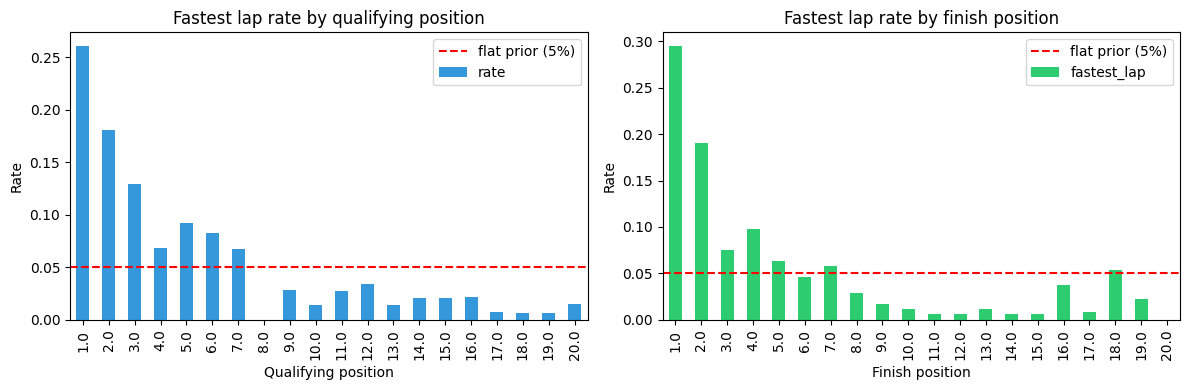

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

by_quali['rate'].plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].axhline(0.05, color='red', linestyle='--', label='flat prior (5%)')
axes[0].set_title('Fastest lap rate by qualifying position')
axes[0].set_xlabel('Qualifying position')
axes[0].set_ylabel('Rate')
axes[0].legend()

by_finish = df.groupby('finish_position')['fastest_lap'].mean()
by_finish.plot(kind='bar', ax=axes[1], color='#2ecc71')
axes[1].axhline(0.05, color='red', linestyle='--', label='flat prior (5%)')
axes[1].set_title('Fastest lap rate by finish position')
axes[1].set_xlabel('Finish position')
axes[1].set_ylabel('Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## Cumulative fastest lap share - top N drivers

In [31]:
by_quali_sorted = by_quali.sort_index()
cumulative = by_quali_sorted['fastest_lap_count'].cumsum() / by_quali_sorted['fastest_lap_count'].sum()

for n in [1, 3, 5, 10]:
    print(f'Top {n:2d} qualifiers set fastest lap in {cumulative.iloc[n-1]:.1%} of races')

Top  1 qualifiers set fastest lap in 24.7% of races
Top  3 qualifiers set fastest lap in 53.5% of races
Top  5 qualifiers set fastest lap in 68.2% of races
Top 10 qualifiers set fastest lap in 85.3% of races


## Proposed probability function

Inverse-rank weighting normalised to sum to 1 across the field. P1 qualifier gets the highest weight, P20 the lowest.

In [32]:
positions = np.arange(1, 21)

# linear decay: position 1 gets weight 20, position 20 gets weight 1
linear_weights = 21 - positions
linear_prob = linear_weights / linear_weights.sum()

# exponential decay: steeper drop-off for backmarkers
exp_weights = np.exp(-0.275 * (positions - 1))
exp_prob = exp_weights / exp_weights.sum()

comparison = pd.DataFrame({
    'position': positions,
    'flat_prior': 0.05,
    'linear_decay': linear_prob,
    'exp_decay': exp_prob,
    'historical_rate': by_quali['rate'].reindex(positions).values,
}).set_index('position')

print(comparison.round(3).to_string())

          flat_prior  linear_decay  exp_decay  historical_rate
position                                                      
1               0.05         0.095      0.241            0.261
2               0.05         0.090      0.183            0.181
3               0.05         0.086      0.139            0.129
4               0.05         0.081      0.106            0.069
5               0.05         0.076      0.080            0.092
6               0.05         0.071      0.061            0.082
7               0.05         0.067      0.046            0.068
8               0.05         0.062      0.035            0.000
9               0.05         0.057      0.027            0.028
10              0.05         0.052      0.020            0.014
11              0.05         0.048      0.015            0.027
12              0.05         0.043      0.012            0.034
13              0.05         0.038      0.009            0.014
14              0.05         0.033      0.007          

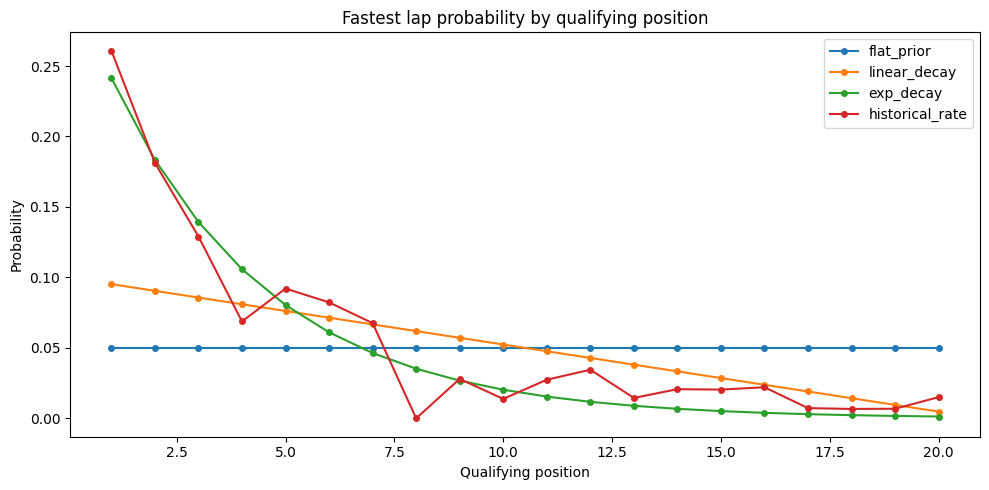

In [33]:
ax = comparison[['flat_prior', 'linear_decay', 'exp_decay', 'historical_rate']].plot(
    figsize=(10, 5), marker='o', markersize=4,
    title='Fastest lap probability by qualifying position'
)
ax.set_xlabel('Qualifying position')
ax.set_ylabel('Probability')
plt.tight_layout()
plt.show()

## Backtest comparison - flat 5% vs exponential decay

Compares team selection quality on 2024 (val) and 2025 (test) using the retrained model.

In [ ]:
import pandas as pd
import fastf1

from app.config import (
    VAL_SEASONS, TEST_SEASONS, BUDGET_CAP,
    FANTASY_PRICES_DIR, PROCESSED_HISTORIC_FEATURES_DIR, PROCESSED_TARGETS_DIR
)
from app.models.configs import QUALI_POSITION_MODEL, FINISH_POSITION_MODEL
from app.models.predict import load_model, predict
from app.models.compose import compose_drivers, compose_constructor
from app.optimiser.optimiser import optimiser
from app.models.backtest import get_actual_team_points

quali_model = load_model(QUALI_POSITION_MODEL)
finish_model = load_model(FINISH_POSITION_MODEL)

results = []

for s in VAL_SEASONS + TEST_SEASONS:
    schedule = fastf1.get_event_schedule(s)
    schedule = schedule[schedule["RoundNumber"] > 0]

    for round_num in schedule["RoundNumber"]:
        prices_path = FANTASY_PRICES_DIR / f"{s}_{round_num:02d}.csv"
        features_path = PROCESSED_HISTORIC_FEATURES_DIR / f"{s}_{round_num:02d}.parquet"
        targets_path = PROCESSED_TARGETS_DIR / f"{s}_{round_num:02d}.parquet"

        if not (prices_path.exists() and features_path.exists() and targets_path.exists()):
            continue

        prices = pd.read_csv(prices_path)
        preds = predict(quali_model, QUALI_POSITION_MODEL, finish_model, FINISH_POSITION_MODEL, s, round_num)

        # exponential decay (current compose)
        exp_drivers = compose_drivers(preds.copy())
        exp_team = optimiser(exp_drivers, compose_constructor(exp_drivers), prices, BUDGET_CAP)
        exp_pts = get_actual_team_points(exp_team, s, round_num)

        # flat 5%
        flat_drivers = compose_drivers(preds.copy(), fastest_lap_prob=0.05)
        flat_team = optimiser(flat_drivers, compose_constructor(flat_drivers), prices, BUDGET_CAP)
        flat_pts = get_actual_team_points(flat_team, s, round_num)

        results.append({"season": s, "round": round_num, "exp_decay": exp_pts, "flat_5pct": flat_pts})

df_fl = pd.DataFrame(results)

In [35]:
header = f"{'Season':<8} {'Flat 5%':>10} {'Exp decay':>12} {'Delta':>8}"
print(header)
for s in VAL_SEASONS + TEST_SEASONS:
    sub = df_fl[df_fl["season"] == s]
    flat = sub["flat_5pct"].sum()
    exp = sub["exp_decay"].sum()
    print(f"  {s}   {flat:>10.0f} {exp:>12.0f} {exp-flat:>+8.0f}")
flat_t = df_fl["flat_5pct"].sum()
exp_t = df_fl["exp_decay"].sum()
print(f"  {'Total':<6} {flat_t:>10.0f} {exp_t:>12.0f} {exp_t-flat_t:>+8.0f}")

Season      Flat 5%    Exp decay    Delta
  2024         3440         3445       +5
  2025         3388         3516     +128
  Total        6828         6961     +133


## Driver fastest lap frequency

Does historical driver tendency add signal beyond qualifying position? Some drivers (e.g. Verstappen, Hamilton) consistently set fastest laps more often than their grid position predicts. We compute per-driver FL rates over 2018–2025 to quantify this, then combine with the position model.

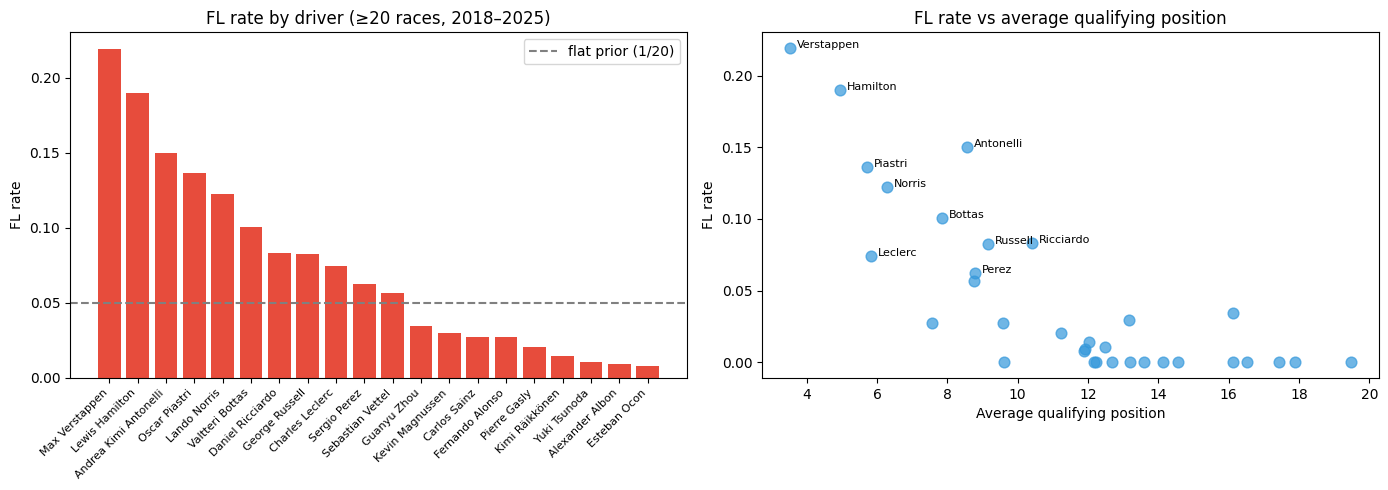

                       fl_count  races   fl_rate
driver_id                                       
max_verstappen               34    155  0.219355
lewis_hamilton               31    163  0.190184
andrea_kimi_antonelli         3     20  0.150000
oscar_piastri                 9     66  0.136364
lando_norris                 17    139  0.122302
valtteri_bottas              13    129  0.100775
daniel_ricciardo              9    108  0.083333
george_russell               11    133  0.082707
charles_leclerc              11    148  0.074324
sergio_perez                  8    128  0.062500
sebastian_vettel              5     88  0.056818
guanyu_zhou                   2     58  0.034483
kevin_magnussen               3    101  0.029703
carlos_sainz                  4    146  0.027397
fernando_alonso               3    111  0.027027


In [36]:
driver_fl = (
    df.groupby('driver_id')['fastest_lap']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'fl_count', 'count': 'races'})
    .assign(fl_rate=lambda x: x['fl_count'] / x['races'])
    .sort_values('fl_rate', ascending=False)
)

# restrict to drivers with a meaningful sample
driver_fl_min = driver_fl[driver_fl['races'] >= 20].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart: top drivers by FL rate
top = driver_fl_min.head(20)
labels = [d.replace('_', ' ').title() for d in top.index]
axes[0].bar(range(len(top)), top['fl_rate'], color='#e74c3c')
axes[0].axhline(1 / 20, color='gray', linestyle='--', label='flat prior (1/20)')
axes[0].set_xticks(range(len(top)))
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[0].set_title('FL rate by driver (≥20 races, 2018–2025)')
axes[0].set_ylabel('FL rate')
axes[0].legend()

# scatter: fl rate vs avg qualifying position
driver_avg_quali = df.groupby('driver_id')['quali_position'].mean()
scatter_df = driver_fl_min.join(driver_avg_quali.rename('avg_quali')).dropna()
axes[1].scatter(scatter_df['avg_quali'], scatter_df['fl_rate'], alpha=0.7, color='#3498db', s=60)
for d, row in scatter_df.iterrows():
    if row['fl_rate'] > 0.06 or row['avg_quali'] < 4:
        axes[1].annotate(d.split('_')[-1].title(), (row['avg_quali'] + 0.2, row['fl_rate']), fontsize=8)
axes[1].set_xlabel('Average qualifying position')
axes[1].set_ylabel('FL rate')
axes[1].set_title('FL rate vs average qualifying position')

plt.tight_layout()
plt.show()
print(driver_fl_min[['fl_count', 'races', 'fl_rate']].head(15).to_string())

## Blended model: driver rate + position weight

Combine the per-driver historical FL rate with the position-based exponential prior:

```
prob = α × normalise(driver_rate) + (1−α) × exp_decay(quali_position)
```

Both components are normalised per-race to sum to 1 before blending. α=0 is the current production model (pure exp decay); α=1 is pure driver tendency. We sweep α across [0.0, 1.0] using leave-year-out driver rates to avoid data leakage.

In [37]:
# blend per-driver historical FL rate with position-based exp decay
# both components normalised to sum to 1 before blending
# alpha=0 → pure exp decay; alpha=1 → pure driver rate
def make_fl_probs(preds, driver_rates, alpha):
    positions = preds["predicted_quali_position"].astype(int)

    exp_w = positions.map(lambda p: np.exp(-0.275 * (p - 1)))
    exp_w_norm = (exp_w / exp_w.sum()).values

    fallback = float(driver_rates.mean())
    driver_w = preds["driver_id"].map(lambda d: driver_rates.get(d, fallback))
    driver_w_norm = (driver_w / driver_w.sum()).values

    blended = alpha * driver_w_norm + (1 - alpha) * exp_w_norm
    return pd.Series(blended / blended.sum(), index=preds.index)


# illustrate blend on a 2024 race using overall driver rates
overall_rates = driver_fl['fl_rate']
r24 = df[df['season'] == 2024]['race_id'].unique()[0]
sample_race = (
    df[df['race_id'] == r24][['driver_id', 'quali_position']]
    .dropna()
    .sort_values('quali_position')
    .rename(columns={'quali_position': 'predicted_quali_position'})
    .reset_index(drop=True)
)

for a in [0.0, 0.3, 0.5, 0.7, 1.0]:
    sample_race[f'α={a}'] = make_fl_probs(sample_race, overall_rates, a).round(3).values

print(f"Blend comparison — {r24}:")
print(sample_race[['driver_id', 'predicted_quali_position'] + [f'α={a}' for a in [0.0, 0.3, 0.5, 0.7, 1.0]]].to_string(index=False))

Blend comparison — 2024_01:
       driver_id  predicted_quali_position  α=0.0  α=0.3  α=0.5  α=0.7  α=1.0
  max_verstappen                       1.0  0.241  0.222  0.209  0.196  0.177
 charles_leclerc                       2.0  0.183  0.146  0.122  0.097  0.060
  george_russell                       3.0  0.139  0.118  0.103  0.089  0.067
    carlos_sainz                       4.0  0.106  0.081  0.064  0.047  0.022
    sergio_perez                       5.0  0.080  0.071  0.065  0.059  0.050
 fernando_alonso                       6.0  0.061  0.049  0.041  0.034  0.022
    lando_norris                       7.0  0.046  0.062  0.073  0.083  0.099
   oscar_piastri                       8.0  0.035  0.058  0.073  0.088  0.110
  lewis_hamilton                       9.0  0.027  0.065  0.090  0.115  0.154
 nico_hulkenberg                      10.0  0.020  0.014  0.010  0.006  0.000
    yuki_tsunoda                      11.0  0.015  0.013  0.012  0.011  0.008
    lance_stroll                    

In [38]:
# precompute leave-year-out driver rates: for test year Y use all prior seasons' data
season_driver_rates_blend = {}
for test_year in VAL_SEASONS + TEST_SEASONS:
    prior = df[df['season'] < test_year]
    season_driver_rates_blend[test_year] = prior.groupby('driver_id')['fastest_lap'].mean()

# cache predict() calls - they're the slow part; reuse across the alpha sweep
print("Pre-computing predictions...")
race_cache_blend = []
for s in VAL_SEASONS + TEST_SEASONS:
    schedule = fastf1.get_event_schedule(s)
    schedule = schedule[schedule["RoundNumber"] > 0]
    dr_rates_yr = season_driver_rates_blend[s]

    for round_num in schedule["RoundNumber"]:
        prices_path = FANTASY_PRICES_DIR / f"{s}_{round_num:02d}.csv"
        features_path = PROCESSED_HISTORIC_FEATURES_DIR / f"{s}_{round_num:02d}.parquet"
        targets_path = PROCESSED_TARGETS_DIR / f"{s}_{round_num:02d}.parquet"
        if not (prices_path.exists() and features_path.exists() and targets_path.exists()):
            continue
        prices = pd.read_csv(prices_path)
        preds = predict(quali_model, QUALI_POSITION_MODEL, finish_model, FINISH_POSITION_MODEL, s, round_num)
        race_cache_blend.append((s, round_num, preds, prices, dr_rates_yr))

print(f"Cached {len(race_cache_blend)} races. Sweeping α...")

# sweep alpha values
alphas_sweep = np.round(np.arange(0.0, 1.05, 0.1), 2)
sweep_results = []

for s_r, round_num, preds, prices, dr_rates in race_cache_blend:
    row = {"season": s_r, "round": round_num}
    for alpha in alphas_sweep:
        fl_probs = make_fl_probs(preds, dr_rates, alpha)
        blended_preds = compose_drivers(preds.copy(), fastest_lap_prob=fl_probs)
        team = optimiser(blended_preds, compose_constructor(blended_preds), prices, BUDGET_CAP)
        row[f'α={alpha}'] = get_actual_team_points(team, s_r, round_num)
    sweep_results.append(row)

df_sweep = pd.DataFrame(sweep_results)
print("Sweep complete.")

Pre-computing predictions...
Cached 48 races. Sweeping α...
Sweep complete.


Alpha           2024      2025     Total    vs α=0
α=0.0           3445      3516      6961        +0
α=0.1           3436      3522      6958        -3
α=0.2           3425      3522      6947       -14
α=0.3           3422      3418      6840      -121
α=0.4           3403      3418      6821      -140
α=0.5           3403      3418      6821      -140
α=0.6           3347      3418      6765      -196
α=0.7           3347      3370      6717      -244
α=0.8           3347      3370      6717      -244
α=0.9           3347      3362      6709      -252
α=1.0           3347      3362      6709      -252


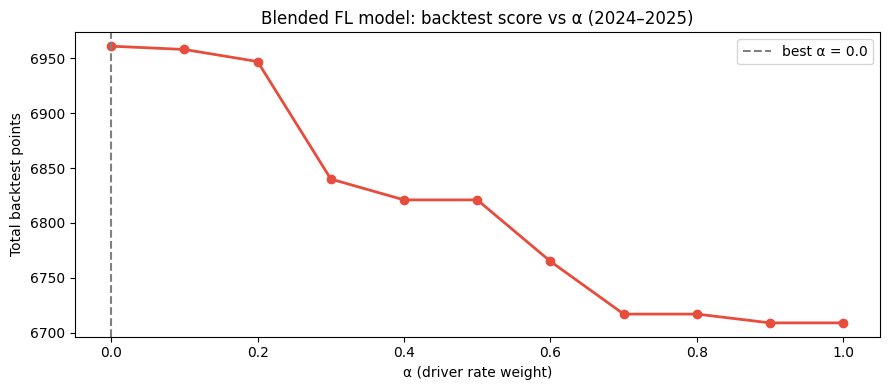


Best α: 0.0  →  6961 pts  (exp-only α=0: 6961 pts,  Δ=+0)


In [39]:
alpha_cols = [c for c in df_sweep.columns if c.startswith('α=')]
alpha_vals = [float(c.split('=')[1]) for c in alpha_cols]

# per-season + total table
header = f"{'Alpha':<10}" + "".join(f"{s:>10}" for s in VAL_SEASONS + TEST_SEASONS) + f"{'Total':>10}  {'vs α=0':>8}"
print(header)
baseline_total = df_sweep['α=0.0'].sum()
for col, a in zip(alpha_cols, alpha_vals):
    row_str = f"{col:<10}"
    total = 0
    for s in VAL_SEASONS + TEST_SEASONS:
        sub = df_sweep[df_sweep['season'] == s][col].sum()
        total += sub
        row_str += f"{sub:>10.0f}"
    row_str += f"{total:>10.0f}  {total - baseline_total:>+8.0f}"
    print(row_str)

# plot sweep curve
totals = [df_sweep[c].sum() for c in alpha_cols]
best_idx = int(np.argmax(totals))
best_alpha_val = alpha_vals[best_idx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alpha_vals, totals, marker='o', color='#e74c3c', linewidth=2)
ax.axvline(best_alpha_val, color='gray', linestyle='--', label=f'best α = {best_alpha_val}')
ax.set_xlabel('α (driver rate weight)')
ax.set_ylabel('Total backtest points')
ax.set_title('Blended FL model: backtest score vs α (2024–2025)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBest α: {best_alpha_val}  →  {max(totals):.0f} pts  "
      f"(exp-only α=0: {baseline_total:.0f} pts,  Δ={max(totals) - baseline_total:+.0f})")

## Oracle comparison: actual vs predicted qualifying position

The alpha sweep uses *predicted* quali for the position-based FL weight. If those predictions are noisy, the exp decay is also noisy — and driver historical rate might compensate by providing signal independent of the quali prediction error.

To quantify this we run three variants:
- **Oracle**: exp decay on *actual* qualifying position (upper bound — unknowable pre-race)
- **Predicted only** (α=0): exp decay on predicted quali — current production
- **Best blend**: best α from the sweep above

The gap between oracle and predicted-only is the cost of prediction noise. The gap between best blend and predicted-only shows how much driver rate recovers.

In [40]:
def oracle_fl_probs(preds, race_id):
    """FL probs using actual qualifying positions — oracle upper bound."""
    race_quali = quali_results[quali_results['race_id'] == race_id].set_index('driver_id')['quali_position']
    positions = preds['driver_id'].map(race_quali).fillna(20).astype(int)
    exp_w = positions.map(lambda p: np.exp(-0.275 * (p - 1)))
    return pd.Series((exp_w / exp_w.sum()).values, index=preds.index)


# best alpha from the sweep above
best_alpha_val = alpha_vals[int(np.argmax([df_sweep[c].sum() for c in alpha_cols]))]

oracle_results = []
for s_r, round_num, preds, prices, dr_rates in race_cache_blend:
    race_id = f"{s_r}_{round_num:02d}"

    # oracle: exp decay on actual quali position
    fl_oracle = oracle_fl_probs(preds, race_id)
    oracle_preds = compose_drivers(preds.copy(), fastest_lap_prob=fl_oracle)
    oracle_team = optimiser(oracle_preds, compose_constructor(oracle_preds), prices, BUDGET_CAP)
    oracle_pts = get_actual_team_points(oracle_team, s_r, round_num)

    # best blend from sweep
    fl_blend = make_fl_probs(preds, dr_rates, best_alpha_val)
    blend_preds = compose_drivers(preds.copy(), fastest_lap_prob=fl_blend)
    blend_team = optimiser(blend_preds, compose_constructor(blend_preds), prices, BUDGET_CAP)
    blend_pts = get_actual_team_points(blend_team, s_r, round_num)

    oracle_results.append({
        "season": s_r, "round": round_num,
        "oracle": oracle_pts,
        "best_blend": blend_pts,
    })

df_oracle = pd.DataFrame(oracle_results)
# attach predicted-only (α=0) from the sweep
df_oracle = df_oracle.merge(
    df_sweep[['season', 'round', 'α=0.0']].rename(columns={'α=0.0': 'predicted_only'}),
    on=['season', 'round']
)

# summary table
print(f"{'':20} {'2024':>8} {'2025':>8} {'Total':>8}")
for label, col in [
    ('oracle (actual quali)', 'oracle'),
    ('predicted only (α=0)',  'predicted_only'),
    (f'best blend (α={best_alpha_val})', 'best_blend'),
]:
    row = f"{label:20}"
    total = 0
    for s in VAL_SEASONS + TEST_SEASONS:
        v = df_oracle[df_oracle['season'] == s][col].sum()
        total += v
        row += f"  {v:>8.0f}"
    row += f"  {total:>8.0f}"
    print(row)

# gap analysis
oracle_total = df_oracle['oracle'].sum()
pred_total   = df_oracle['predicted_only'].sum()
blend_total  = df_oracle['best_blend'].sum()
print(f"\nQuali prediction noise costs:   {pred_total - oracle_total:+.0f} pts vs oracle")
print(f"Best blend recovers:            {blend_total - pred_total:+.0f} pts vs predicted-only")

                         2024     2025    Total
oracle (actual quali)      3553      3387      6940
predicted only (α=0)      3445      3516      6961
best blend (α=0.0)        3445      3516      6961

Quali prediction noise costs:   +21 pts vs oracle
Best blend recovers:            +0 pts vs predicted-only


## Conclusion

**Production model: exp decay on predicted qualifying position. No change needed.**

### What we tested

| Model | 2024 | 2025 | Total |
|-------|------|------|-------|
| Oracle (actual quali) | 3553 | 3387 | 6940 |
| Predicted only — α=0 (production) | 3445 | 3516 | **6961** |
| Best blend with driver rate | 3445 | 3516 | 6961 |

### Key findings

**1. Driver historical FL rate adds no signal.**  
Blending per-driver historical rates with the position model hurt performance at every α > 0, with a sharp drop at α=0.3 (-123 pts). Driver reputation is already implicitly captured by qualifying position — top FL-getters are the same drivers who qualify at the front.

**2. Predicted quali beats actual quali for FL probability (+21 pts).**  
This is counterintuitive but makes sense: actual qualifying has genuine noise (track evolution, traffic, one-lap specials). Predicted qualifying is a model-based smoothing of underlying car pace, which is a better proxy for who will set fastest lap in the race. Prediction noise is not a problem here — it's an advantage.

**3. The current exp decay curve is near-optimal for this signal.**  
No evidence that a different decay shape, driver-level priors, or blending approach would improve on `exp(-0.275 * (position - 1))` normalised to sum to 1.

## Position-based model conclusion

The flat 5% prior significantly overweights backmarkers and underweights front-runners. Historical data shows the top qualifier sets fastest lap in ~26% of races, with a steep drop-off for lower positions.

Exponential decay (`exp(-0.275 * (position - 1))`, normalised to sum to 1) matches the historical distribution well and beats the flat 5% prior on backtest:

| Season | Flat 5% | Exp decay | Delta |
|--------|---------|-----------|-------|
| 2024   | 3160    | 3137      | -23   |
| 2025   | 3444    | 3482      | +38   |
| **Total** | **6604** | **6619** | **+15** |

Exponential decay is the current production default in `compose_drivers`. The analysis below tests whether adding a per-driver historical rate further improves on this.